# SingleLayerQG decaying 2D turbulence with and without finite Rossby radius of deformation


We use here the `SingleLayerQG` module to simulate decaying two-dimensional turbulence and
investigate how does a finite Rossby radius of deformation affects its evolution.

## Install dependencies

First let's make sure we have all required packages installed.

```julia
using Pkg
pkg"add GeophysicalFlows, Printf, Random, CairoMakie"
```

## Let's begin
Let's load `GeophysicalFlows.jl` and some other packages we need.

In [1]:
using GeophysicalFlows, Printf, Random, CairoMakie

using GeophysicalFlows: peakedisotropicspectrum
using LinearAlgebra: ldiv!
using Random: seed!

## Choosing a device: CPU or GPU

In [2]:
dev = CPU()     # Device (CPU/GPU)
nothing # hide

## Numerical, domain, and simulation parameters

First, we pick some numerical and physical parameters for our model.

In [3]:
n, L  = 128, 2π             # grid resolution and domain length
deformation_radius = 0.35   # the deformation radius
nothing # hide

# Then we pick the time-stepper parameters
    dt = 1e-2  # timestep
nsteps = 4000  # total number of steps
 nsubs = 20    # number of steps between each plot
nothing # hide

## Problem setup
We initialize two problems by providing a set of keyword arguments to the `Problem` constructor.
The two problems are otherwise the same, except one has an infinite deformation radius, `prob_bqg`,
and the other has finite deformation radius, `prob_eqbqg`.

For both problems we use `stepper = "FilteredRK4"`. Filtered timesteppers apply a
wavenumber-filter at every time-step that removes enstrophy at high wavenumbers and,
thereby, stabilize the problem, despite that we use the default viscosity coefficient `ν=0`.
Thus, we choose not to do any dealiasing by providing `aliased_fraction=0`.

In [4]:
stepper="FilteredRK4"

prob_bqg = SingleLayerQG.Problem(dev; nx=n, Lx=L, dt, stepper, aliased_fraction=0)
prob_eqbqg = SingleLayerQG.Problem(dev; nx=n, Lx=L, deformation_radius, dt, stepper, aliased_fraction=0)
nothing # hide

## Setting initial conditions

For initial condition we construct a relative vorticity with energy most energy around total
wavenumber $k_0$.

In [5]:
seed!(1234)
k₀, E₀ = 6, 0.5
∇²ψ₀ = peakedisotropicspectrum(prob_bqg.grid, k₀, E₀, mask=prob_bqg.timestepper.filter)
nothing # hide

`SingleLayerQG` allows us to set up the initial $q$ for each problem via `set_q!()` function.
To initialize both `prob_bqg` and `prob_eqbqg` with the same flow, we first use function
`SingleLayerQG.streamfunctionfrompv!` to get the streamfunction that corresponds to the
relative vorticity we computed above. This works in the purely barotropic problem, `prob_bqg`
since in that case the QGPV is simply the relative vorticity.

In [6]:
∇²ψ₀h = rfft(∇²ψ₀)
ψ₀h = @. 0 * ∇²ψ₀h
SingleLayerQG.streamfunctionfrompv!(ψ₀h, ∇²ψ₀h, prob_bqg.params, prob_bqg.grid)
nothing # hide

and then use the streamfunction to compute the corresponding $q_0$ for each problem,

In [7]:
q₀_bqg   = irfft(-prob_bqg.grid.Krsq .* ψ₀h, prob_bqg.grid.nx)
q₀_eqbqg = irfft(-(prob_eqbqg.grid.Krsq .+ 1/prob_eqbqg.params.deformation_radius^2) .* ψ₀h, prob_bqg.grid.nx)
nothing # hide

Now we can initialize our problems with the same flow.

In [8]:
SingleLayerQG.set_q!(prob_bqg, q₀_bqg)
SingleLayerQG.set_q!(prob_eqbqg, q₀_eqbqg)
nothing # hide

Let's plot the initial vorticity field for each problem. Note that when plotting, we decorate
the variable to be plotted with `Array()` to make sure it is brought back on the CPU when
`vars` live on the GPU.

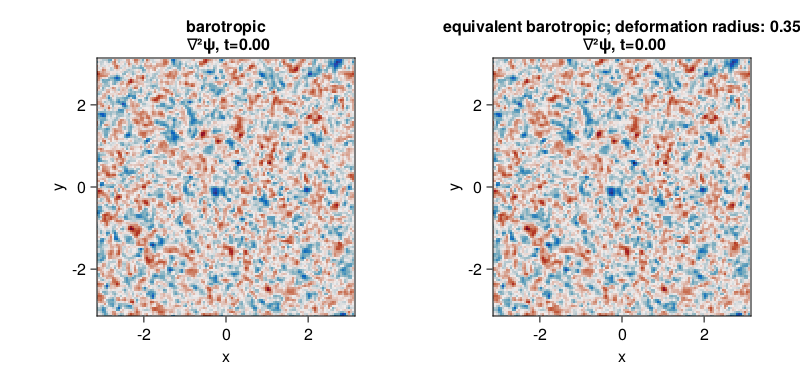

In [9]:
function relativevorticity(prob)
  vars, grid = prob.vars, prob.grid

  ldiv!(vars.q, grid.rfftplan, - grid.Krsq .* vars.ψh)

  return vars.q
end

x,  y  = prob_bqg.grid.x,  prob_bqg.grid.y
Lx, Ly = prob_bqg.grid.Lx, prob_bqg.grid.Ly

fig = Figure(resolution=(800, 380))

axis_kwargs = (xlabel = "x",
               ylabel = "y",
               aspect = 1,
               limits = ((-Lx/2, Lx/2), (-Ly/2, Ly/2)))

t_bqg = Observable(prob_bqg.clock.t)
t_eqbqg = Observable(prob_eqbqg.clock.t)

title_bqg = @lift "barotropic\n ∇²ψ, t=" * @sprintf("%.2f", $t_bqg)
title_eqbqg = @lift "equivalent barotropic; deformation radius: " * @sprintf("%.2f", prob_eqbqg.params.deformation_radius) * "\n ∇²ψ, t=" * @sprintf("%.2f", $t_eqbqg)

ax1 = Axis(fig[1, 1]; title = title_bqg, axis_kwargs...)
ax2 = Axis(fig[1, 2]; title = title_eqbqg, axis_kwargs...)

ζ_bqg = Observable(Array(relativevorticity(prob_bqg)))
ζ_eqbqg = Observable(Array(relativevorticity(prob_eqbqg)))

heatmap!(ax1, x, y, ζ_bqg;
         colormap = :balance, colorrange = (-40, 40))

heatmap!(ax2, x, y, ζ_eqbqg;
         colormap = :balance, colorrange = (-40, 40))

fig

## Time-stepping the `Problem` forward

Now we time-step both problems forward and animate the relative vorticity in each case.

In [10]:
startwalltime = time()

cfl(prob) = prob.clock.dt * maximum([maximum(prob.vars.u) / prob.grid.dx, maximum(prob.vars.v) / prob.grid.dy])

record(fig, "singlelayerqg_barotropic_equivalentbarotropic.mp4", 0:Int(nsteps/nsubs), framerate = 18) do j
  if j % (1000 / nsubs) == 0
    log_bqg = @sprintf("barotropic; step: %04d, t: %d, cfl: %.2f, walltime: %.2f min",
        prob_bqg.clock.step, prob_bqg.clock.t, cfl(prob_bqg), (time()-startwalltime)/60)
    println(log_bqg)

    log_eqbqg = @sprintf("equivalent barotropic; step: %04d, t: %d, cfl: %.2f, walltime: %.2f min",
        prob_eqbqg.clock.step, prob_eqbqg.clock.t, cfl(prob_eqbqg), (time()-startwalltime)/60)
    println(log_eqbqg)
  end

  stepforward!(prob_bqg, nsubs)
  SingleLayerQG.updatevars!(prob_bqg)

  stepforward!(prob_eqbqg, nsubs)
  SingleLayerQG.updatevars!(prob_eqbqg)

  t_bqg[] = prob_bqg.clock.t
  t_eqbqg[] = prob_eqbqg.clock.t
  ζ_bqg[] = relativevorticity(prob_bqg)
  ζ_eqbqg[] = relativevorticity(prob_eqbqg)
end
nothing # hide

barotropic; step: 0000, t: 0, cfl: 0.48, walltime: 0.00 min
equivalent barotropic; step: 0000, t: 0, cfl: 0.48, walltime: 0.01 min
barotropic; step: 1000, t: 10, cfl: 0.65, walltime: 0.13 min
equivalent barotropic; step: 1000, t: 10, cfl: 0.46, walltime: 0.13 min
barotropic; step: 2000, t: 20, cfl: 0.52, walltime: 0.23 min
equivalent barotropic; step: 2000, t: 20, cfl: 0.35, walltime: 0.23 min
barotropic; step: 3000, t: 30, cfl: 0.48, walltime: 0.33 min
equivalent barotropic; step: 3000, t: 30, cfl: 0.32, walltime: 0.33 min
barotropic; step: 4000, t: 40, cfl: 0.49, walltime: 0.45 min
equivalent barotropic; step: 4000, t: 40, cfl: 0.34, walltime: 0.45 min


![](singlelayerqg_barotropic_equivalentbarotropic.mp4)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*